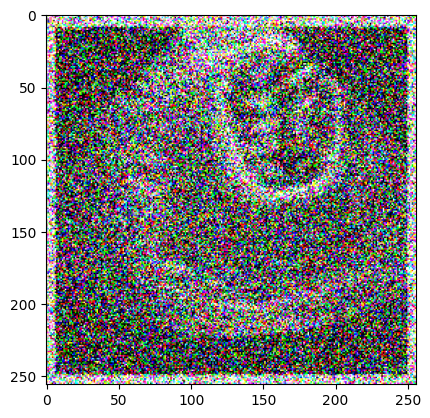

1


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.0035539323..0.99825585].


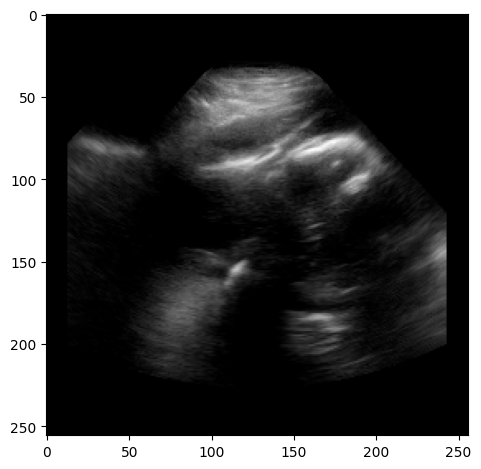

In [8]:
import torch
from matplotlib import pyplot as plt
import numpy as np
from monai_model import DDPMPL
from torchvision.transforms import transforms
from PIL import Image

hparams = {
    'lr': 1e-4,
    'weight_decay': 1e-5,
    'num_train_timesteps': 1000,
    'in_channels': 3,
    'out_channels': 3,
    'use_pre_trained': False
}
guidance_path = "/mnt/raid/home/ajarry/data/ultrasound.png"
model = DDPMPL(**hparams)

device = torch.device("cuda")

# Generate a sample
state_dict = torch.load("/mnt/raid/home/ajarry/data/outputs_monai/working_output/model.pth")
model.load_state_dict(state_dict, strict=False)
model = model.to(device)

shape = (1, 3, 256,256)  # Adjust based on model's requirements
image = Image.open(guidance_path).convert('RGB')
transform = transforms.Compose([
            transforms.Resize((256, 256)),
            transforms.ToTensor(),
 ])
image = transform(image).unsqueeze(0)
noise =  torch.randn(shape)
noisy_image = torch.clamp(image+noise*0.8,0,1)
noisy_image = noisy_image.to(device)
plt.figure(1)
plt.imshow(noisy_image.cpu().squeeze().numpy().transpose(1,2,0))
plt.show()

# List to store generated samples
samples = []

# Generate 8 samples
model.eval()
iter = 0
sample_number = 1
with torch.no_grad():
    for _ in range(sample_number):
        iter+=1
        print(iter)
        # Generate a random sample

        sample = model(noisy_image, timesteps=torch.tensor([800])).cpu().squeeze()  # Generate image and move to CPU
        samples.append(sample)

# # Plot the 8 samples in a 2x4 grid
# fig, axes = plt.subplots(2,4)
# for i, ax in enumerate(axes.flat):
#     # Transpose the sample to (H, W, C) and convert to numpy for plotting
#     img = samples[i].numpy().transpose(1, 2, 0)
#     ax.imshow(img)
#     ax.axis('off')

for i in range(sample_number):
    img = samples[i].numpy().transpose(1,2,0)

plt.figure(2)
plt.imshow(img)
plt.tight_layout()
plt.show()